<a href="https://colab.research.google.com/github/Aer-3888/EDA_Housing/blob/main/EDA_Immobillier_france_covid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis on Housing Prices in Pays de la Loire, France

## Project Overview
This project aims to analyze housing prices in Pays de la Loire, France, with a particular focus on understanding how the COVID-19 pandemic has influenced pricing trends. Through exploratory data analysis (EDA), we will examine key factors affecting housing prices, identify trends over time, and assess any shifts in the market before, during, and after the pandemic.

## Objectives
- Analyze the distribution and trends of housing prices in the region.
- Identify key factors influencing price variations.
- Study the impact of COVID-19 on the housing market by comparing pre-pandemic, pandemic, and post-pandemic data.
- Visualize pricing trends and correlations using statistical and graphical methods.

## Methodology
- Data Cleaning and Preprocessing
- Descriptive Statistics
- Data Visualization (e.g., time series plots, histograms, scatter plots, heatmaps)
- Feature Analysis and Correlation Study
- Comparative Analysis of Pre-COVID, COVID, and Post-COVID Trends

## Data Source
The dataset used for this analysis is sourced from [data.gouv.fr](https://www.data.gouv.fr/fr/datasets/indicateurs-immobiliers-par-commune-et-par-annee-prix-et-volumes-sur-la-periode-2014-2023/#/resources), which provides real estate indicators by municipality and year for the period 2014-2023.

## Tools & Libraries
- Python
- Pandas
- Matplotlib & Seaborn
- NumPy
- Scikit-learn (if applicable for further analysis)


## Data Cleaning and Processing

In [45]:
# Import tools and libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.colors import Normalize

In [46]:
# Download URLs for each year from data.gouv.fr
DVF_URLS = {
    2014: 'https://static.data.gouv.fr/resources/indicateurs-immobiliers-par-commune-et-par-annee-prix-et-volumes-sur-la-periode-2014-2021/20240418-112248/dvf2014.csv',
    2015: 'https://static.data.gouv.fr/resources/indicateurs-immobiliers-par-commune-et-par-annee-prix-et-volumes-sur-la-periode-2014-2021/20240418-112249/dvf2015.csv',
    2016: 'https://static.data.gouv.fr/resources/indicateurs-immobiliers-par-commune-et-par-annee-prix-et-volumes-sur-la-periode-2014-2021/20240418-112249/dvf2016.csv',
    2017: 'https://static.data.gouv.fr/resources/indicateurs-immobiliers-par-commune-et-par-annee-prix-et-volumes-sur-la-periode-2014-2021/20240418-112249/dvf2017.csv',
    2018: 'https://static.data.gouv.fr/resources/indicateurs-immobiliers-par-commune-et-par-annee-prix-et-volumes-sur-la-periode-2014-2021/20240418-112250/dvf2018.csv',
    2019: 'https://static.data.gouv.fr/resources/indicateurs-immobiliers-par-commune-et-par-annee-prix-et-volumes-sur-la-periode-2014-2021/20240418-112250/dvf2019.csv',
    2020: 'https://static.data.gouv.fr/resources/indicateurs-immobiliers-par-commune-et-par-annee-prix-et-volumes-sur-la-periode-2014-2021/20240418-112251/dvf2020.csv',
    2021: 'https://static.data.gouv.fr/resources/indicateurs-immobiliers-par-commune-et-par-annee-prix-et-volumes-sur-la-periode-2014-2021/20240418-112251/dvf2021.csv',
    2022: 'https://static.data.gouv.fr/resources/indicateurs-immobiliers-par-commune-et-par-annee-prix-et-volumes-sur-la-periode-2014-2021/20240418-112252/dvf2022.csv',
    2023: 'https://static.data.gouv.fr/resources/indicateurs-immobiliers-par-commune-et-par-annee-prix-et-volumes-sur-la-periode-2014-2021/20240418-112252/dvf2023.csv',
}

# Local cache directory (works on Colab, local, anywhere)
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

# Load CSVs: download from data.gouv.fr if not cached locally
dfs = []
for year, url in DVF_URLS.items():
    local_path = DATA_DIR / f'dvf{year}.csv'
    if not local_path.exists():
        print(f'Downloading dvf{year}.csv...')
        df = pd.read_csv(url)
        df.to_csv(local_path, index=False)
    else:
        df = pd.read_csv(local_path)
    dfs.append(df)

print(f'Loaded {len(dfs)} files.')

Loaded 10 files.


In [47]:
# Concatenate all data into one dataframe
data = pd.concat(dfs, axis=0, ignore_index=True)
data.dtypes

Unnamed: 0        int64
INSEE_COM           str
Annee             int64
Nb_mutations      int64
NbMaisons       float64
NbApparts       float64
propmaison      float64
propappart      float64
PrixMoyen       float64
Prixm2Moyen     float64
SurfaceMoy      float64
dtype: object

In [48]:
data.shape

(290766, 11)

In [49]:
# Filter data to keep only municipalities from the target region, here Pays de la Loire
# Pays de la loire contains 5 department:
#   44 – Loire-Atlantique
#   49 – Maine-et-Loire
#   53 – Mayenne
#   72 – Sarthe
#   85 – Vendée


department_include = {
    44 : 'Loire-Atlantique',
    49 : 'Maine-et-Loire',
    53 : 'Mayenne',
    72 : 'Sarthe',
    85 : 'Vendée'
}

In [50]:
# Here we can find out the region thanks to the first 2 number of the insee code of each municipalities
insee_first_2_code = data['INSEE_COM'].str.extract(r'^(\d{2})')[0] # Extract first 2 number
insee_first_2_code = insee_first_2_code.apply(lambda x : -1 if pd.isna(x) else int(x)) # Convert from string to int
region_filter = (insee_first_2_code.isin(department_include.keys()))
data_region = data[region_filter].copy()
data_region

,Unnamed: 0,INSEE_COM,Annee,Nb_mutations,NbMaisons,NbApparts,propmaison,propappart,PrixMoyen,Prixm2Moyen,SurfaceMoy
13494,13495,44001,2014,14,14.0,0.0,100.000000,0.000000,98821.428571,1404.642857,76.000000
13495,13496,44002,2014,34,34.0,0.0,100.000000,0.000000,204500.000000,2065.617647,101.911765
13496,13497,44003,2014,79,53.0,26.0,67.088608,32.911392,156780.430380,1809.696203,91.721519
13497,13498,44005,2014,61,60.0,1.0,98.360656,1.639344,158866.557377,1856.672131,87.737705
13498,13499,44006,2014,32,32.0,0.0,100.000000,0.000000,172073.437500,2260.687500,79.343750
...,...,...,...,...,...,...,...,...,...,...,...
288950,28196,85302,2023,54,54.0,0.0,100.000000,0.000000,203007.444444,2143.740741,103.333333
288951,28197,85303,2023,24,24.0,0.0,100.000000,0.000000,161741.666667,1568.166667,103.541667
288952,28198,85304,2023,7,7.0,0.0,100.000000,0.000000,168881.142857,1649.285714,107.428571
288953,28199,85305,2023,20,18.0,2.0,90.000000,10.000000,184615.500000,1504.250000,123.750000


In [51]:
# Map the department name to each municipalities
data_region.loc[:, 'Departement'] = insee_first_2_code.apply(lambda x: department_include[x] if x in department_include else "")

data_region


,Unnamed: 0,INSEE_COM,Annee,Nb_mutations,NbMaisons,NbApparts,propmaison,propappart,PrixMoyen,Prixm2Moyen,SurfaceMoy,Departement
13494,13495,44001,2014,14,14.0,0.0,100.000000,0.000000,98821.428571,1404.642857,76.000000,Loire-Atlantique
13495,13496,44002,2014,34,34.0,0.0,100.000000,0.000000,204500.000000,2065.617647,101.911765,Loire-Atlantique
13496,13497,44003,2014,79,53.0,26.0,67.088608,32.911392,156780.430380,1809.696203,91.721519,Loire-Atlantique
13497,13498,44005,2014,61,60.0,1.0,98.360656,1.639344,158866.557377,1856.672131,87.737705,Loire-Atlantique
13498,13499,44006,2014,32,32.0,0.0,100.000000,0.000000,172073.437500,2260.687500,79.343750,Loire-Atlantique
...,...,...,...,...,...,...,...,...,...,...,...,...
288950,28196,85302,2023,54,54.0,0.0,100.000000,0.000000,203007.444444,2143.740741,103.333333,Vendée
288951,28197,85303,2023,24,24.0,0.0,100.000000,0.000000,161741.666667,1568.166667,103.541667,Vendée
288952,28198,85304,2023,7,7.0,0.0,100.000000,0.000000,168881.142857,1649.285714,107.428571,Vendée
288953,28199,85305,2023,20,18.0,2.0,90.000000,10.000000,184615.500000,1504.250000,123.750000,Vendée


In [52]:
# Clean the dataframe by retaining the relevant data and removing unnecessary columns

data_region = data_region.drop(columns=['Unnamed: 0', 'Nb_mutations', 'NbMaisons','NbApparts', 'propmaison', 'propappart'])

In [53]:
data_region

,INSEE_COM,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy,Departement
13494,44001,2014,98821.428571,1404.642857,76.000000,Loire-Atlantique
13495,44002,2014,204500.000000,2065.617647,101.911765,Loire-Atlantique
13496,44003,2014,156780.430380,1809.696203,91.721519,Loire-Atlantique
13497,44005,2014,158866.557377,1856.672131,87.737705,Loire-Atlantique
13498,44006,2014,172073.437500,2260.687500,79.343750,Loire-Atlantique
...,...,...,...,...,...,...
288950,85302,2023,203007.444444,2143.740741,103.333333,Vendée
288951,85303,2023,161741.666667,1568.166667,103.541667,Vendée
288952,85304,2023,168881.142857,1649.285714,107.428571,Vendée
288953,85305,2023,184615.500000,1504.250000,123.750000,Vendée


## Data Preparation

Before splitting into analysis periods, we perform a full data quality audit on the 12,071 filtered records: resolving missing values, removing invalid entries, treating outliers, and validating formats to establish a clean foundation for exploratory analytics.

In [54]:
# Initial data audit
rows_before = len(data_region)

print(f"Shape: {data_region.shape}")
print(f"\nData types:\n{data_region.dtypes}")

print(f"\nMissing values per column:")
missing = data_region.isnull().sum()
print(missing[missing > 0] if missing.any() else "  None found")

n_dupes = data_region.duplicated(subset=['INSEE_COM', 'Annee']).sum()
print(f"\nDuplicate (INSEE_COM, Annee) pairs: {n_dupes}")

Shape: (12071, 6)

Data types:
INSEE_COM          str
Annee            int64
PrixMoyen      float64
Prixm2Moyen    float64
SurfaceMoy     float64
Departement        str
dtype: object

Missing values per column:
  None found

Duplicate (INSEE_COM, Annee) pairs: 0


In [55]:
# Drop rows where any key metric column is NaN
data_region = data_region.dropna(subset=['PrixMoyen', 'Prixm2Moyen', 'SurfaceMoy']).copy()
rows_after_null_drop = len(data_region)
print(f"Rows removed (NaN in metrics): {rows_before - rows_after_null_drop}")
print(f"Rows remaining               : {rows_after_null_drop:,}")

Rows removed (NaN in metrics): 0
Rows remaining               : 12,071


In [56]:
# Remove rows with zero or negative metric values
invalid_mask = (
    (data_region['PrixMoyen'] <= 0) |
    (data_region['Prixm2Moyen'] <= 0) |
    (data_region['SurfaceMoy'] <= 0)
)
n_invalid = invalid_mask.sum()
print(f"Rows with zero or negative values: {n_invalid}")
data_region = data_region[~invalid_mask].copy()
rows_after_invalid_drop = len(data_region)
print(f"Rows remaining: {rows_after_invalid_drop:,}")

Rows with zero or negative values: 0
Rows remaining: 12,071


In [57]:
# Detect outliers using the 1.5xIQR method
metric_cols = ['PrixMoyen', 'Prixm2Moyen', 'SurfaceMoy']
lower_bounds = {}
upper_bounds = {}
outlier_counts = {}

for col in metric_cols:
    Q1 = data_region[col].quantile(0.25)
    Q3 = data_region[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bounds[col] = Q1 - 1.5 * IQR
    upper_bounds[col] = Q3 + 1.5 * IQR
    n_out = ((data_region[col] < lower_bounds[col]) | (data_region[col] > upper_bounds[col])).sum()
    outlier_counts[col] = n_out
    print(f"{col}:")
    print(f"  IQR fence : [{lower_bounds[col]:.0f}, {upper_bounds[col]:.0f}]")
    print(f"  Outliers  : {n_out} ({n_out / len(data_region) * 100:.1f}%)")

PrixMoyen:
  IQR fence : [5854, 276621]
  Outliers  : 395 (3.3%)
Prixm2Moyen:
  IQR fence : [148, 2740]
  Outliers  : 610 (5.1%)
SurfaceMoy:
  IQR fence : [62, 135]
  Outliers  : 571 (4.7%)


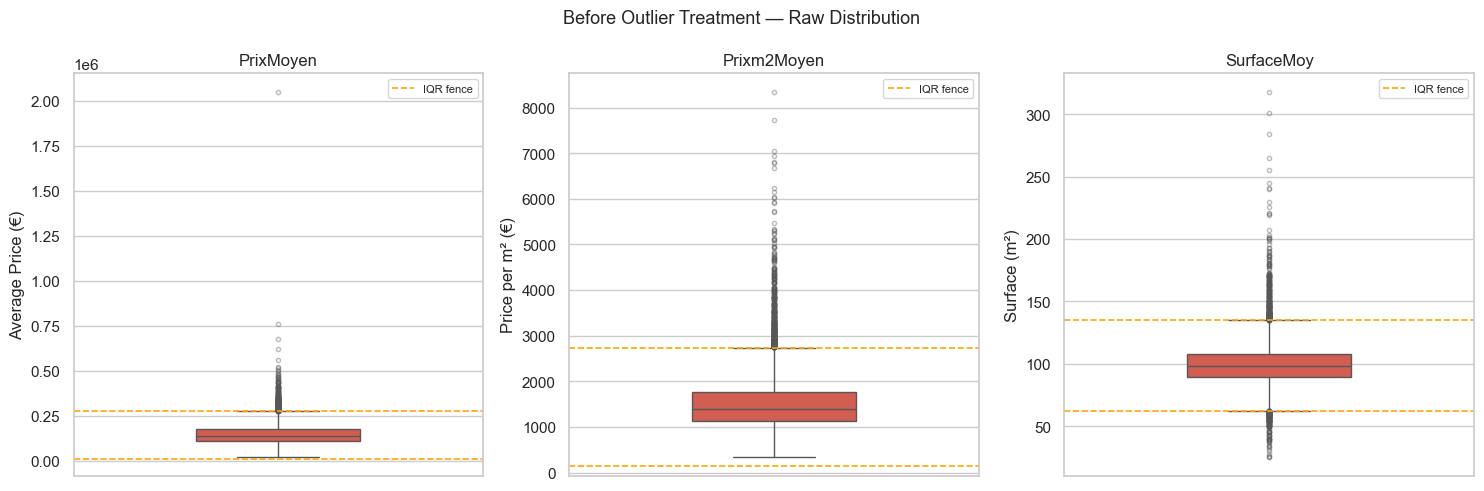

In [58]:
# Boxplot of the raw distribution before outlier treatment
col_labels = ['Average Price (€)', 'Price per m² (€)', 'Surface (m²)']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Before Outlier Treatment — Raw Distribution', fontsize=13)

for ax, col, label in zip(axes, metric_cols, col_labels):
    sns.boxplot(y=data_region[col], ax=ax, color='#e74c3c', width=0.4,
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
    ax.axhline(upper_bounds[col], color='orange', linestyle='--', linewidth=1.2, label='IQR fence')
    ax.axhline(max(lower_bounds[col], 0), color='orange', linestyle='--', linewidth=1.2)
    ax.set_title(col)
    ax.set_ylabel(label)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [59]:
# Cap outliers at IQR fences (Winsorizing)
for col in metric_cols:
    data_region[col] = data_region[col].clip(lower=lower_bounds[col], upper=upper_bounds[col])

print("Outliers capped. Value ranges after Winsorizing:")
print(data_region[metric_cols].agg(['min', 'max']).round(2))

Outliers capped. Value ranges after Winsorizing:
     PrixMoyen  Prixm2Moyen  SurfaceMoy
min    17500.0       331.00       62.38
max   276620.6      2740.13      135.14


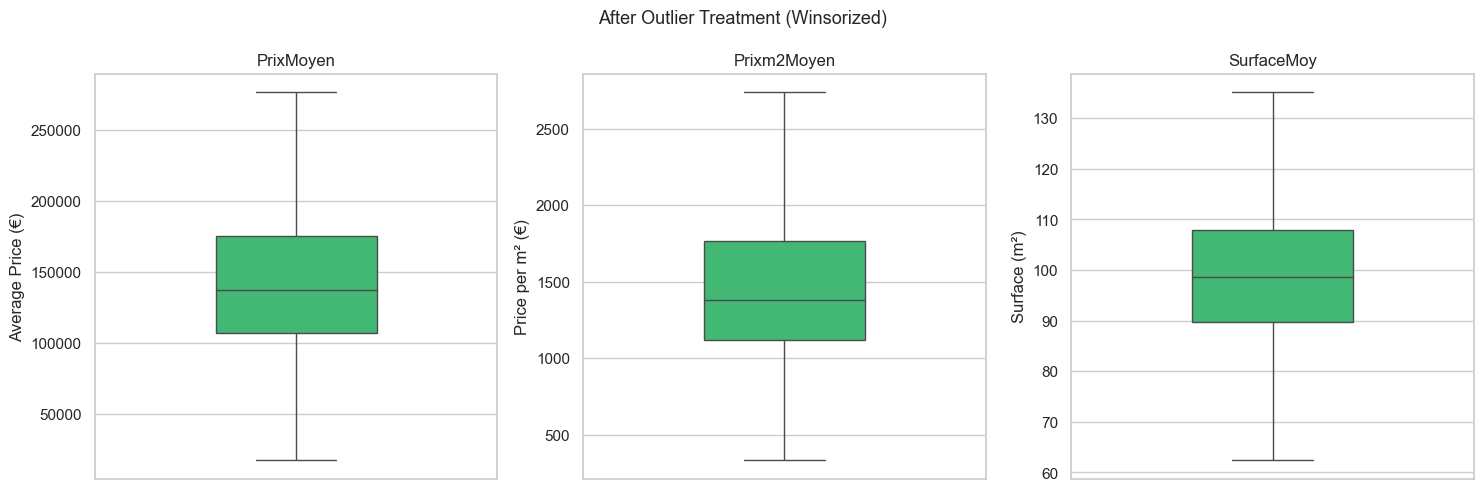

In [60]:
# Boxplot of the distribution after outlier treatment (Winsorized)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('After Outlier Treatment (Winsorized)', fontsize=13)

for ax, col, label in zip(axes, metric_cols, col_labels):
    sns.boxplot(y=data_region[col], ax=ax, color='#2ecc71', width=0.4,
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
    ax.set_title(col)
    ax.set_ylabel(label)

plt.tight_layout()
plt.show()

In [61]:
# Validate INSEE_COM format and enforce data types
valid_format = data_region['INSEE_COM'].str.match(r'^\d{5}$') # Must be a 5-character numeric string
invalid_insee = (~valid_format).sum()
print(f"Invalid INSEE_COM format: {invalid_insee} rows")

data_region['Annee'] = data_region['Annee'].astype(int)
for col in metric_cols:
    data_region[col] = data_region[col].astype(float)

print("\nData types after enforcement:")
print(data_region.dtypes)

Invalid INSEE_COM format: 0 rows

Data types after enforcement:
INSEE_COM          str
Annee            int64
PrixMoyen      float64
Prixm2Moyen    float64
SurfaceMoy     float64
Departement        str
dtype: object


In [62]:
# Data preparation summary
print("=" * 50)
print("  DATA PREPARATION SUMMARY")
print("=" * 50)
print(f"  Initial rows            : {rows_before:,}")
print(f"  Removed (NaN values)    : {rows_before - rows_after_null_drop:,}")
print(f"  Removed (invalid <= 0)  : {rows_after_null_drop - rows_after_invalid_drop:,}")
print(f"  Final rows              : {rows_after_invalid_drop:,}")
print()
print(f"  Outliers capped (1.5xIQR):")
for col in metric_cols:
    print(f"    {col}: {outlier_counts[col]:,} values capped")
print()
print(f"  Invalid INSEE codes     : {invalid_insee}")
print(f"  Final shape             : {data_region.shape}")
print(f"  Remaining missing values: {data_region[metric_cols].isnull().sum().sum()}")
print("=" * 50)

  DATA PREPARATION SUMMARY
  Initial rows            : 12,071
  Removed (NaN values)    : 0
  Removed (invalid <= 0)  : 0
  Final rows              : 12,071

  Outliers capped (1.5xIQR):
    PrixMoyen: 395 values capped
    Prixm2Moyen: 610 values capped
    SurfaceMoy: 571 values capped

  Invalid INSEE codes     : 0
  Final shape             : (12071, 6)
  Remaining missing values: 0


In [63]:
# Split the dataframe into three time periods:
#   - Pre-COVID (2014-2019)
#   - COVID period (2020-2021, as the dataset only contains yearly data)
#   - Post-COVID (2022 and beyond)
# Since the dataset only includes years (not months), we consider COVID to have ended after 2021.
# Note: These periods are based on the region considered, and the starting period may vary in other countries.

df_pre_covid = data_region[data_region['Annee'] <= 2019]
df_covid = data_region[(data_region['Annee'] >= 2020) & (data_region['Annee'] <= 2021)]
df_post_covid = data_region[data_region['Annee'] > 2021]

In [64]:
df_ventes = data_region.groupby('Annee').size().reset_index(name='Nombre de ventes')

## Data statistics

### **Pre-COVID Housing Market Overview**  
Before COVID-19, the housing market exhibited notable variations in pricing, property size, and sales activity. The average house price across the period was approximately **€133,493**, with a median price of **€127,706**, highlighting a mix of affordability and higher-end transactions. Prices ranged from **€18,000** to **€276,621**, reflecting significant disparities between different locations and property types.

The average price per square meter stood at **€1,384**, with a spread from **€333/m² to €2,740/m²**, indicating the influence of both urban and rural housing markets. Similarly, the average home size was **98.3m²**, with most properties falling between **88m² and 107m²**, and a maximum of **135.1m²**.

On average, **around 1,197 properties were sold per year** during this period, showing consistent market activity. Market trends showed a gradual increase in prices and property values, suggesting growing demand, especially in later years. This pre-pandemic stability set the stage for potential disruptions and shifts in the housing market once COVID-19 emerged.

In [65]:
df_pre_covid.describe()

,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy
count,7180.000000,7180.000000,7180.000000,7180.000000
mean,2016.501671,133492.814179,1383.806489,98.313165
std,1.713778,46951.208819,465.697942,16.224414
min,2014.000000,18000.000000,333.000000,62.380952
25%,2015.000000,101081.000000,1066.766667,88.333333
50%,2016.000000,127706.419118,1295.422222,97.820938
75%,2018.000000,158920.973958,1609.635417,107.765224
max,2019.000000,276620.604396,2740.132197,135.142857


In [66]:
df_pre_covid.groupby('Annee').size().reset_index(name='Nombre de ventes')

,Annee,Nombre de ventes
0,2014,1195
1,2015,1205
2,2016,1213
3,2017,1162
4,2018,1180
5,2019,1225


In [67]:
for year in range(2014,2020):
    display(df_pre_covid[df_pre_covid['Annee'] == year])

,INSEE_COM,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy,Departement
13494,44001,2014,98821.428571,1404.642857,76.000000,Loire-Atlantique
13495,44002,2014,204500.000000,2065.617647,101.911765,Loire-Atlantique
13496,44003,2014,156780.430380,1809.696203,91.721519,Loire-Atlantique
13497,44005,2014,158866.557377,1856.672131,87.737705,Loire-Atlantique
13498,44006,2014,172073.437500,2260.687500,79.343750,Loire-Atlantique
...,...,...,...,...,...,...
25918,85302,2014,124328.232558,1293.883721,103.651163,Vendée
25919,85303,2014,99220.000000,1034.000000,101.266667,Vendée
25920,85304,2014,133400.000000,1321.181818,103.545455,Vendée
25921,85305,2014,99272.727273,1038.090909,95.000000,Vendée


,INSEE_COM,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy,Departement
41481,44001,2015,102142.857143,1291.928571,84.785714,Loire-Atlantique
41482,44002,2015,186730.310345,1763.103448,108.931034,Loire-Atlantique
41483,44003,2015,190387.446429,1912.071429,100.839286,Loire-Atlantique
41484,44005,2015,169447.131148,1858.442623,93.016393,Loire-Atlantique
41485,44006,2015,158105.714286,1836.190476,87.761905,Loire-Atlantique
...,...,...,...,...,...,...
54116,85302,2015,115448.717949,1280.461538,90.820513,Vendée
54117,85303,2015,125095.312500,990.312500,130.250000,Vendée
54118,85304,2015,97212.500000,1238.375000,88.000000,Vendée
54119,85305,2015,146496.250000,1146.000000,129.166667,Vendée


,INSEE_COM,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy,Departement
69761,44001,2016,136979.411765,1668.058824,95.529412,Loire-Atlantique
69762,44002,2016,176145.588235,1858.294118,95.117647,Loire-Atlantique
69763,44003,2016,143341.521739,1688.228261,87.565217,Loire-Atlantique
69764,44005,2016,167761.538462,1906.046154,91.092308,Loire-Atlantique
69765,44006,2016,182004.000000,1916.966667,96.566667,Loire-Atlantique
...,...,...,...,...,...,...
82503,85302,2016,131787.500000,1352.516667,96.800000,Vendée
82504,85303,2016,121802.631579,1221.842105,103.526316,Vendée
82505,85304,2016,114750.000000,1194.000000,97.000000,Vendée
82506,85305,2016,92745.416667,1006.750000,88.583333,Vendée


,INSEE_COM,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy,Departement
97181,44001,2017,118000.000000,1482.500000,79.750000,Loire-Atlantique
97182,44002,2017,187727.272727,2078.000000,90.681818,Loire-Atlantique
97183,44003,2017,195112.428571,1906.836735,104.591837,Loire-Atlantique
97184,44005,2017,190298.033898,1912.711864,103.745763,Loire-Atlantique
97185,44006,2017,157610.809524,2068.428571,80.904762,Loire-Atlantique
...,...,...,...,...,...,...
109315,85302,2017,129370.200000,1402.320000,93.800000,Vendée
109316,85303,2017,98118.181818,1108.545455,84.636364,Vendée
109317,85304,2017,134857.142857,1150.142857,113.000000,Vendée
109318,85305,2017,101275.000000,978.083333,111.333333,Vendée


,INSEE_COM,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy,Departement
124046,44001,2018,136964.285714,1467.214286,94.214286,Loire-Atlantique
124047,44002,2018,182112.185185,1899.407407,103.296296,Loire-Atlantique
124048,44003,2018,170861.111111,1989.166667,84.944444,Loire-Atlantique
124049,44005,2018,196174.000000,2145.015625,94.890625,Loire-Atlantique
124050,44006,2018,197418.823529,2125.823529,102.294118,Loire-Atlantique
...,...,...,...,...,...,...
136364,85302,2018,141155.172414,1438.310345,103.241379,Vendée
136365,85303,2018,129986.666667,1156.600000,113.866667,Vendée
136366,85304,2018,109053.750000,1175.750000,96.125000,Vendée
136367,85305,2018,117550.000000,1256.250000,96.375000,Vendée


,INSEE_COM,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy,Departement
152731,44001,2019,139237.500000,1400.812500,106.375000,Loire-Atlantique
152732,44002,2019,198823.809524,2308.523810,91.309524,Loire-Atlantique
152733,44003,2019,206312.500000,2170.764706,97.029412,Loire-Atlantique
152734,44005,2019,188435.403846,1990.692308,97.259615,Loire-Atlantique
152735,44006,2019,180677.235294,2345.205882,82.176471,Loire-Atlantique
...,...,...,...,...,...,...
166438,85302,2019,156963.275862,1558.068966,103.241379,Vendée
166439,85303,2019,130971.363636,1147.727273,118.500000,Vendée
166440,85304,2019,119370.000000,1393.600000,90.900000,Vendée
166441,85305,2019,133989.421053,1175.052632,114.157895,Vendée


### **COVID-19 Period Housing Market Overview**  
During the COVID-19 period, the housing market experienced fluctuations in pricing, property sizes, and transaction volumes. The average house price increased to approximately **€154,365**, with a median price of **€145,706**, suggesting an upward shift in home values. Prices ranged from **€17,500** to **€276,621**, reflecting a broad spectrum of property values.

The average price per square meter rose to **€1,550**, compared to the pre-COVID period, with values spanning from **€331/m² to €2,740/m²**. This indicates a continued divergence between different regional markets. The average property size slightly increased to **101.0m²**, with most homes between **92.3m² and 109.2m²**.

Sales volumes remained stable during this period, with an **average of approximately 1,225 transactions per year**.

Despite the challenges brought by the pandemic, the housing market demonstrated resilience, with rising prices and relatively steady sales activity. However, regional disparities and shifts in buyer preferences may have contributed to changes in property demand and pricing structures.

In [68]:
df_covid.describe()

,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy
count,2450.000000,2450.000000,2450.000000,2450.000000
mean,2020.500000,154365.213689,1550.443630,100.950265
std,0.500102,54516.149818,538.724969,14.200624
min,2020.000000,17500.000000,331.000000,62.380952
25%,2020.000000,114779.058442,1144.281250,92.301677
50%,2020.500000,145705.971223,1425.455882,100.569048
75%,2021.000000,186919.054545,1870.449975,109.226793
max,2021.000000,276620.604396,2740.132197,135.142857


In [69]:
min_year_covid = df_covid['Annee'].min()
max_year_covid = df_covid['Annee'].max()
for year in range(min_year_covid, max_year_covid+1):
    display(df_covid[df_covid['Annee'] == year])

,INSEE_COM,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy,Departement
183049,44001,2020,138911.750000,1569.375000,92.968750,Loire-Atlantique
183050,44002,2020,221262.954545,2374.272727,96.500000,Loire-Atlantique
183051,44003,2020,238587.878788,2246.787879,106.606061,Loire-Atlantique
183052,44005,2020,216318.361446,2147.096386,102.939759,Loire-Atlantique
183053,44006,2020,214479.142857,2575.000000,89.119048,Loire-Atlantique
...,...,...,...,...,...,...
196906,85302,2020,153452.883721,1619.930233,94.162791,Vendée
196907,85303,2020,123072.727273,1209.000000,109.227273,Vendée
196908,85304,2020,141951.105263,1364.894737,114.157895,Vendée
196909,85305,2020,115585.555556,1181.111111,99.370370,Vendée


,INSEE_COM,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy,Departement
213882,44001,2021,155694.444444,1718.592593,98.703704,Loire-Atlantique
213883,44002,2021,259295.000000,2664.900000,97.875000,Loire-Atlantique
213884,44003,2021,217944.852941,2656.705882,85.470588,Loire-Atlantique
213885,44005,2021,226662.689655,2374.810345,98.870690,Loire-Atlantique
213886,44006,2021,228055.238095,2602.500000,91.214286,Loire-Atlantique
...,...,...,...,...,...,...
227973,85302,2021,167448.479452,1763.178082,95.589041,Vendée
227974,85303,2021,155182.361111,1572.083333,103.638889,Vendée
227975,85304,2021,141357.894737,1541.105263,101.526316,Vendée
227976,85305,2021,146198.095238,1361.095238,110.952381,Vendée


In [70]:
df_covid.groupby('Annee').size().reset_index(name='Nombre de ventes')

,Annee,Nombre de ventes
0,2020,1225
1,2021,1225


### **Post-COVID Housing Market Overview**  
Following the COVID-19 period, the housing market continued to evolve, with notable shifts in pricing, property sizes, and sales activity.

The **average house price** in this period was approximately **€172,405**, showing continued growth compared to pre-COVID levels. The **median price** stood at **€165,294**, and the **median price per square meter** reached approximately **€1,654/m²**, indicating sustained demand with signs of market stabilization.

The **average home size** was **98.7m²**, consistent with previous periods, with most properties falling between **90m² and 107m²**.

**Sales volumes remained stable**, averaging **1,220 transactions per year**.

While prices fluctuated between 2022 and 2023, the market showed resilience, with continued demand despite potential economic uncertainties. The housing sector remains dynamic, influenced by factors such as urban migration, inflation, and shifting buyer preferences.

In [71]:
df_post_covid.describe()

,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy
count,2441.000000,2441.000000,2441.000000,2441.000000
mean,2022.498976,172405.478638,1761.669125,98.676156
std,0.500101,58515.705726,564.940669,14.473477
min,2022.000000,20000.000000,407.000000,62.380952
25%,2022.000000,127750.000000,1318.500000,90.100000
50%,2022.000000,165294.111111,1653.666667,98.391304
75%,2023.000000,214129.268293,2190.174603,106.837838
max,2023.000000,276620.604396,2740.132197,135.142857


In [72]:
min_year_covid = df_post_covid['Annee'].min()
max_year_covid = df_post_covid['Annee'].max()
for year in range(min_year_covid, max_year_covid+1):
    display(df_post_covid[df_post_covid['Annee'] == year])

,INSEE_COM,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy,Departement
244871,44001,2022,206280.000000,2092.400000,103.080000,Loire-Atlantique
244872,44002,2022,235138.722222,2467.944444,97.083333,Loire-Atlantique
244873,44003,2022,276620.604396,2740.132197,102.888889,Loire-Atlantique
244874,44005,2022,234155.695652,2734.239130,84.728261,Loire-Atlantique
244875,44006,2022,229074.000000,2740.132197,85.305556,Loire-Atlantique
...,...,...,...,...,...,...
258883,85302,2022,183284.345455,1971.581818,93.818182,Vendée
258884,85303,2022,150018.709677,1388.129032,116.935484,Vendée
258885,85304,2022,170851.500000,1529.714286,112.500000,Vendée
258886,85305,2022,179596.750000,1697.950000,107.950000,Vendée


,INSEE_COM,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy,Departement
275370,44001,2023,163575.772727,1754.318182,97.409091,Loire-Atlantique
275371,44002,2023,276620.604396,2740.132197,101.536585,Loire-Atlantique
275372,44003,2023,248271.152542,2647.406780,95.779661,Loire-Atlantique
275373,44005,2023,246491.915254,2636.152542,92.949153,Loire-Atlantique
275374,44006,2023,271260.526316,2740.132197,94.842105,Loire-Atlantique
...,...,...,...,...,...,...
288950,85302,2023,203007.444444,2143.740741,103.333333,Vendée
288951,85303,2023,161741.666667,1568.166667,103.541667,Vendée
288952,85304,2023,168881.142857,1649.285714,107.428571,Vendée
288953,85305,2023,184615.500000,1504.250000,123.750000,Vendée


In [73]:
df_post_covid.groupby('Annee').size().reset_index(name='Nombre de ventes')

,Annee,Nombre de ventes
0,2022,1223
1,2023,1218


### **Overall Housing Market Overview (2014-2023)**  

Over the past decade, the housing market has undergone significant changes in pricing, property sizes, and sales activity.

- **Average house price:** €145,598  
- **Median house price:** €137,242  
- **Price range:** €17,500 to €276,621  

The **price per square meter** averaged **€1,494/m²**, with values ranging from **€331/m² to €2,740/m²**, reflecting differences between urban and rural areas.

The **average home size** was **98.9m²**, with most properties falling between **89.7m² and 107.9m²**, and a maximum of **135.1m²**.

#### **Sales Activity**  
The number of **property transactions remained relatively stable**, with annual sales averaging around **1,200 to 1,250 per year**.  
Market trends suggest a gradual **increase in property values over time**, with notable accelerations post-2019 before stabilizing post-COVID.

In [74]:
data_region.describe()

,Annee,PrixMoyen,Prixm2Moyen,SurfaceMoy
count,12071.000000,12071.000000,12071.000000,12071.000000
mean,2018.525971,145598.123826,1494.039584,98.921810
std,2.875598,53427.179962,524.173479,15.520845
min,2014.000000,17500.000000,331.000000,62.380952
25%,2016.000000,107391.666667,1119.766667,89.666667
50%,2019.000000,137241.666667,1381.500000,98.538462
75%,2021.000000,175083.241758,1767.912879,107.857143
max,2023.000000,276620.604396,2740.132197,135.142857


In [75]:
# Seaborn set style
sns.set_theme(style="whitegrid")

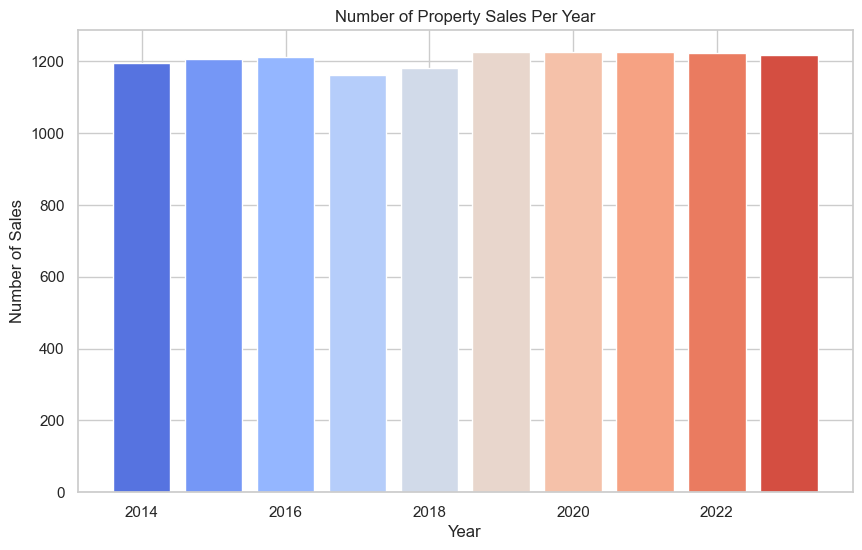

In [76]:
# Figure 1: Number of Sales Per Year

colors = sns.color_palette("coolwarm", len(df_ventes))
plt.figure(figsize=(10, 6))
bars = plt.bar(df_ventes["Annee"], df_ventes["Nombre de ventes"], color=colors)
plt.xlabel("Year")
plt.ylabel("Number of Sales")
plt.title("Number of Property Sales Per Year")
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=Normalize(vmin=df_ventes["Annee"].min(), vmax=df_ventes["Annee"].max()))
plt.show()

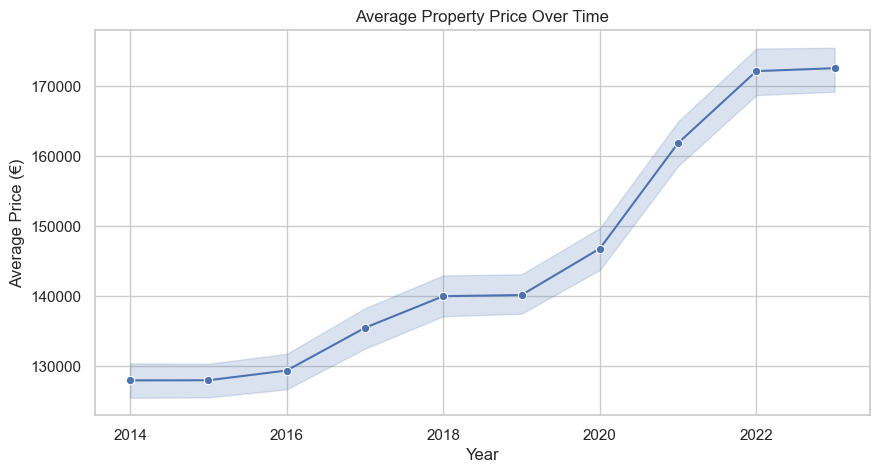

In [77]:
# Figure 2: Average Price Over Time
plt.figure(figsize=(10, 5))
sns.lineplot(x='Annee', y='PrixMoyen', data=data_region, marker='o', color='b')
plt.xlabel("Year")
plt.ylabel("Average Price (€)")
plt.title("Average Property Price Over Time")
plt.grid(True)
plt.show()

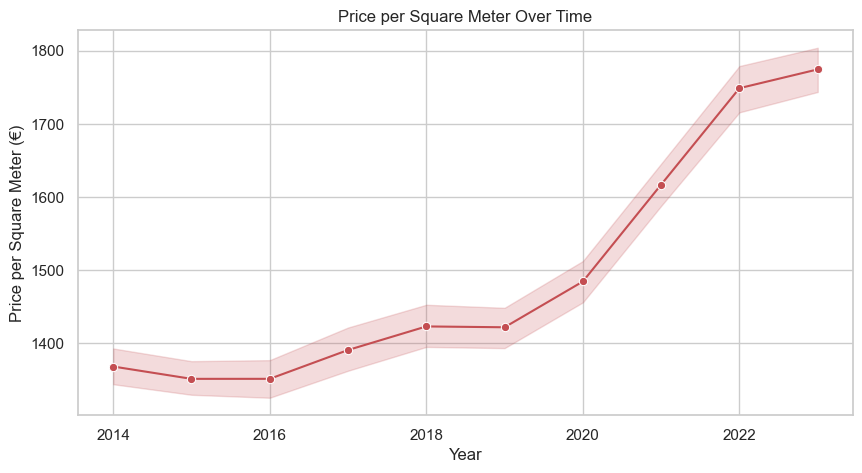

In [78]:
# Figure 3: Price per Square Meter Over Time
plt.figure(figsize=(10, 5))
sns.lineplot(x='Annee', y='Prixm2Moyen', data=data_region, marker='o', color='r')
plt.xlabel("Year")
plt.ylabel("Price per Square Meter (€)")
plt.title("Price per Square Meter Over Time")
plt.grid(True)
plt.show()

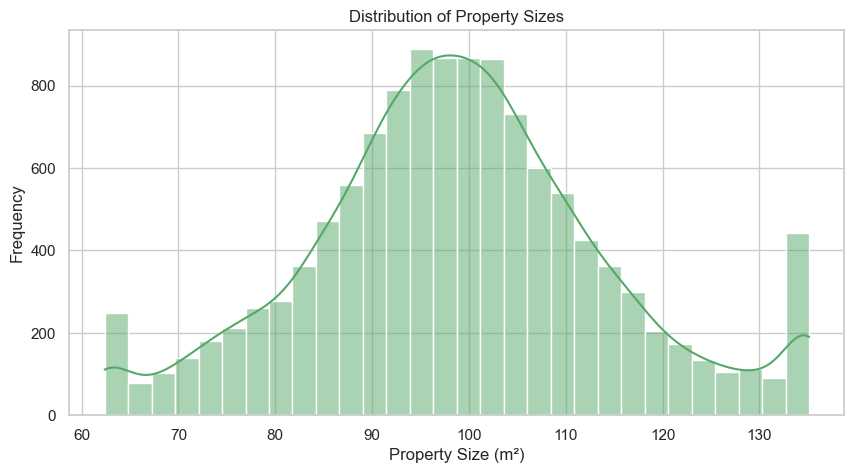

In [79]:
# Figure 4: Distribution of Property Sizes
plt.figure(figsize=(10, 5))
sns.histplot(data_region['SurfaceMoy'], bins=30, kde=True, color='g')
plt.xlabel("Property Size (m²)")
plt.ylabel("Frequency")
plt.title("Distribution of Property Sizes")
plt.show()

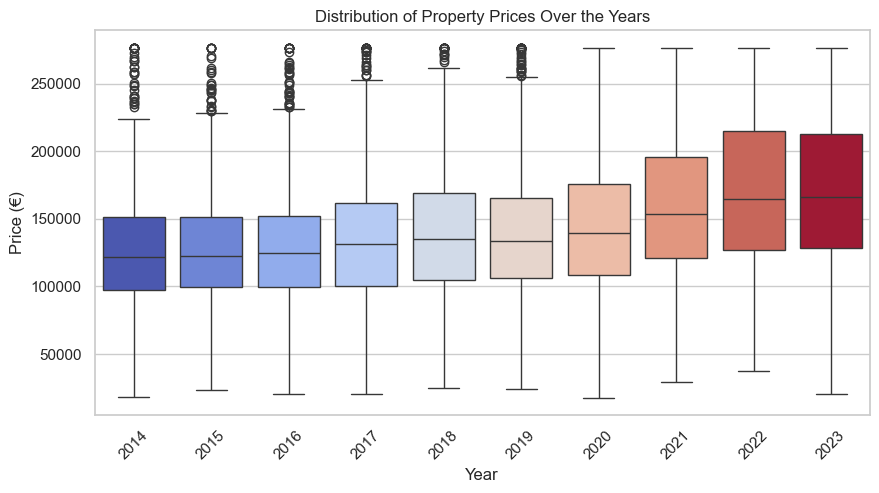

In [80]:
# Figure 5: Boxplot of Prices Over the Years
plt.figure(figsize=(10, 5))
sns.boxplot(x='Annee', y='PrixMoyen', data=data_region, hue='Annee', palette='coolwarm', legend=False)
plt.xlabel("Year")
plt.ylabel("Price (€)")
plt.title("Distribution of Property Prices Over the Years")
plt.xticks(rotation=45)
plt.show()

## Advanced Visualizations

In [81]:
# Additional imports and shared data preparation
import numpy as np
import json
import requests
import folium

# Add department code for GeoJSON matching
data_region['Dept_Code'] = data_region['INSEE_COM'].str[:2]

# Add period label for period-based visualizations
def assign_period(year):
    if year <= 2019:
        return 'Pre-COVID\n(2014-2019)'
    elif year <= 2021:
        return 'COVID\n(2020-2021)'
    else:
        return 'Post-COVID\n(2022-2023)'

data_region['Period'] = data_region['Annee'].apply(assign_period)

### Figure 6: Interactive Choropleth Map
Average price per m² by department across all years. The map uses GeoJSON boundaries from [france-geojson](https://github.com/gregoiredavid/france-geojson) matched on department codes.

In [82]:
# Figure 6: Interactive Choropleth Map — Average Price/m² by Department

# Aggregate mean price/m² per department
dept_avg = data_region.groupby('Dept_Code').agg(
    Prixm2Moyen_mean=('Prixm2Moyen', 'mean'),
    Departement=('Departement', 'first')
).reset_index()

# Fetch and filter GeoJSON to Pays de la Loire departments
geojson_url = 'https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements-version-simplifiee.geojson'
response = requests.get(geojson_url)
geojson_data = response.json()

pdl_codes = ['44', '49', '53', '72', '85']
geojson_data['features'] = [
    f for f in geojson_data['features']
    if f['properties']['code'] in pdl_codes
]

# Create interactive map centered on Pays de la Loire
m = folium.Map(location=[47.4, -1.2], zoom_start=8, tiles='cartodbpositron')

folium.Choropleth(
    geo_data=geojson_data,
    name='choropleth',
    data=dept_avg,
    columns=['Dept_Code', 'Prixm2Moyen_mean'],
    key_on='feature.properties.code',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.5,
    legend_name='Average Price per m² (€)',
    highlight=True
).add_to(m)

# Add department name tooltips
folium.GeoJson(
    geojson_data,
    tooltip=folium.GeoJsonTooltip(
        fields=['nom'],
        aliases=['Department:'],
        style='font-size: 12px;'
    )
).add_to(m)

m

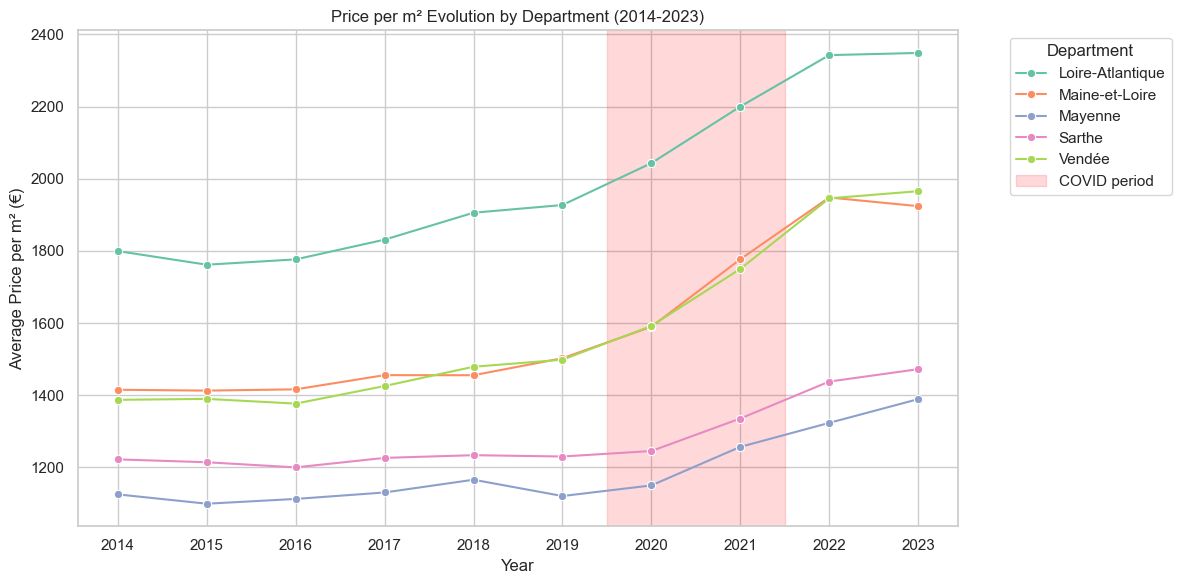

In [83]:
# Figure 7: Price per m² Evolution by Department

dept_yearly = data_region.groupby(['Annee', 'Departement'])['Prixm2Moyen'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=dept_yearly,
    x='Annee', y='Prixm2Moyen',
    hue='Departement',
    marker='o',
    palette='Set2'
)

# COVID period shading
plt.axvspan(2019.5, 2021.5, alpha=0.15, color='red', label='COVID period')

plt.xlabel('Year')
plt.ylabel('Average Price per m² (€)')
plt.title('Price per m² Evolution by Department (2014-2023)')
plt.legend(title='Department', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(range(2014, 2024))
plt.tight_layout()
plt.show()

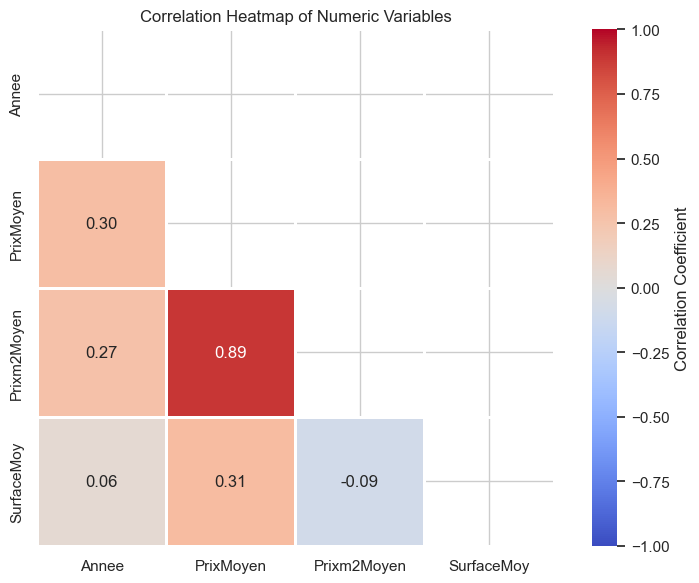

In [84]:
# Figure 8: Correlation Heatmap

numeric_cols = data_region[['Annee', 'PrixMoyen', 'Prixm2Moyen', 'SurfaceMoy']]
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    mask=mask,
    square=True,
    linewidths=1,
    vmin=-1, vmax=1,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Correlation Heatmap of Numeric Variables')
plt.tight_layout()
plt.show()

### COVID Impact Analysis
Comparing housing market indicators across three periods: Pre-COVID (2014-2019), COVID (2020-2021), and Post-COVID (2022-2023).

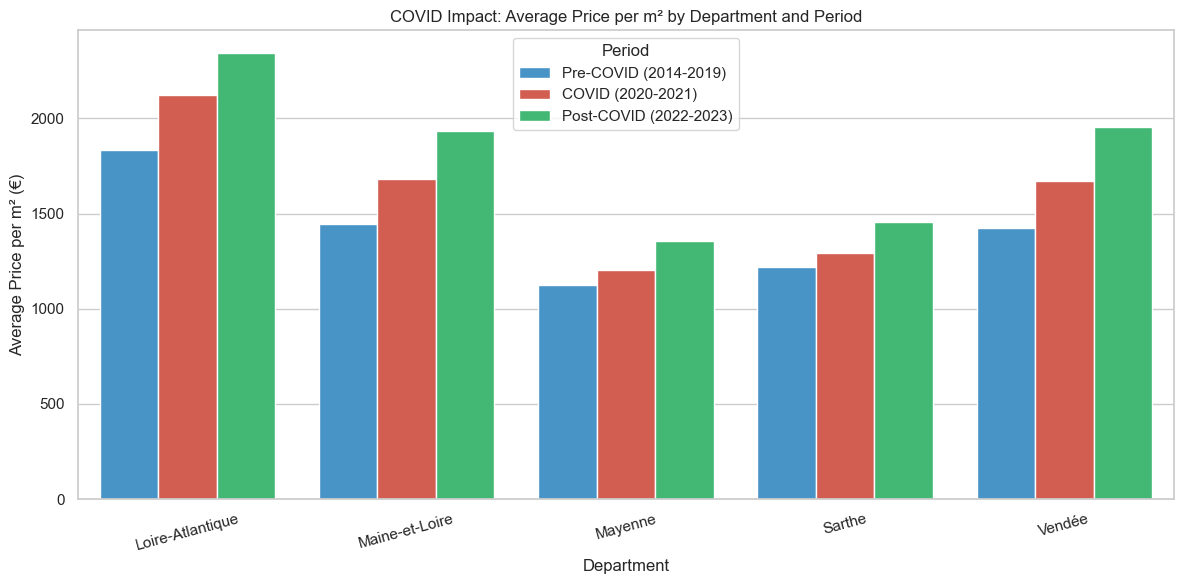

In [85]:
# Figure 9: COVID Impact — Average Price/m² by Department and Period

def period_dept_avg(df, period_name):
    return df.groupby('Departement')['Prixm2Moyen'].mean().reset_index().assign(Period=period_name)

covid_impact = pd.concat([
    period_dept_avg(df_pre_covid, 'Pre-COVID (2014-2019)'),
    period_dept_avg(df_covid, 'COVID (2020-2021)'),
    period_dept_avg(df_post_covid, 'Post-COVID (2022-2023)')
])

plt.figure(figsize=(12, 6))
sns.barplot(
    data=covid_impact,
    x='Departement', y='Prixm2Moyen',
    hue='Period',
    palette=['#3498db', '#e74c3c', '#2ecc71']
)

plt.xlabel('Department')
plt.ylabel('Average Price per m² (€)')
plt.title('COVID Impact: Average Price per m² by Department and Period')
plt.legend(title='Period')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

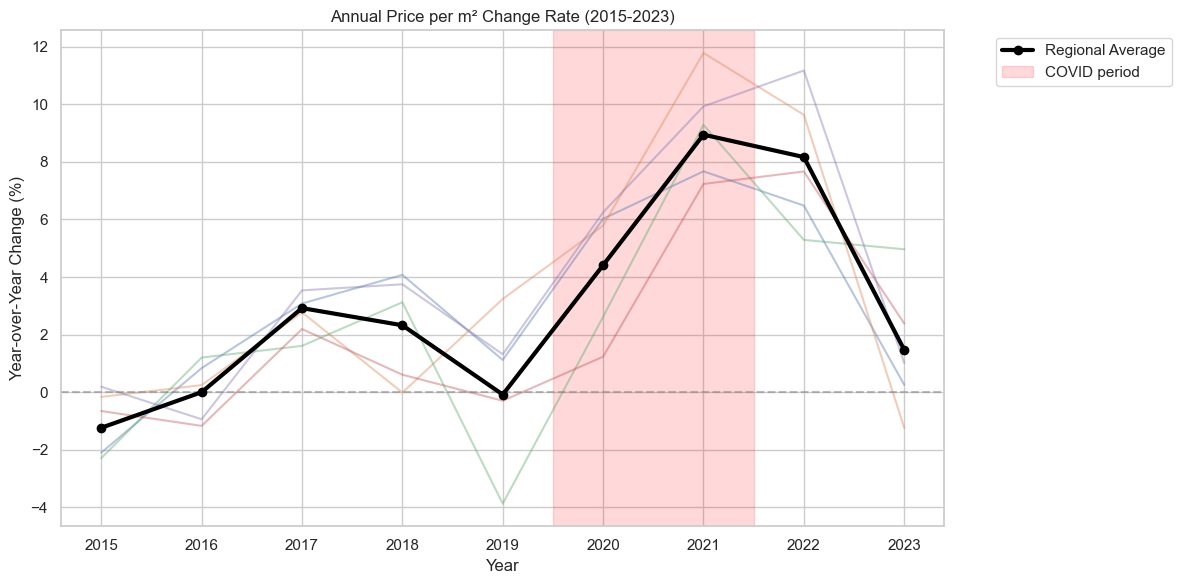

In [86]:
# Figure 10: Year-over-Year Price/m² Change Rate

# Regional average
yearly_avg = data_region.groupby('Annee')['Prixm2Moyen'].mean().reset_index()
yearly_avg['Pct_Change'] = yearly_avg['Prixm2Moyen'].pct_change() * 100

# Per-department
dept_yearly_pct = data_region.groupby(['Annee', 'Departement'])['Prixm2Moyen'].mean().reset_index()
dept_yearly_pct['Pct_Change'] = dept_yearly_pct.groupby('Departement')['Prixm2Moyen'].pct_change() * 100

fig, ax = plt.subplots(figsize=(12, 6))

# Department lines (thin, semi-transparent for context)
sns.lineplot(
    data=dept_yearly_pct.dropna(),
    x='Annee', y='Pct_Change',
    hue='Departement',
    alpha=0.4, linewidth=1.5, legend=False, ax=ax
)

# Regional average (thick, prominent)
ax.plot(
    yearly_avg.dropna()['Annee'],
    yearly_avg.dropna()['Pct_Change'],
    color='black', linewidth=3, marker='o', label='Regional Average', zorder=5
)

# Reference line at 0%
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# COVID period shading
ax.axvspan(2019.5, 2021.5, alpha=0.15, color='red', label='COVID period')

ax.set_xlabel('Year')
ax.set_ylabel('Year-over-Year Change (%)')
ax.set_title('Annual Price per m² Change Rate (2015-2023)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticks(range(2015, 2024))
plt.tight_layout()
plt.show()

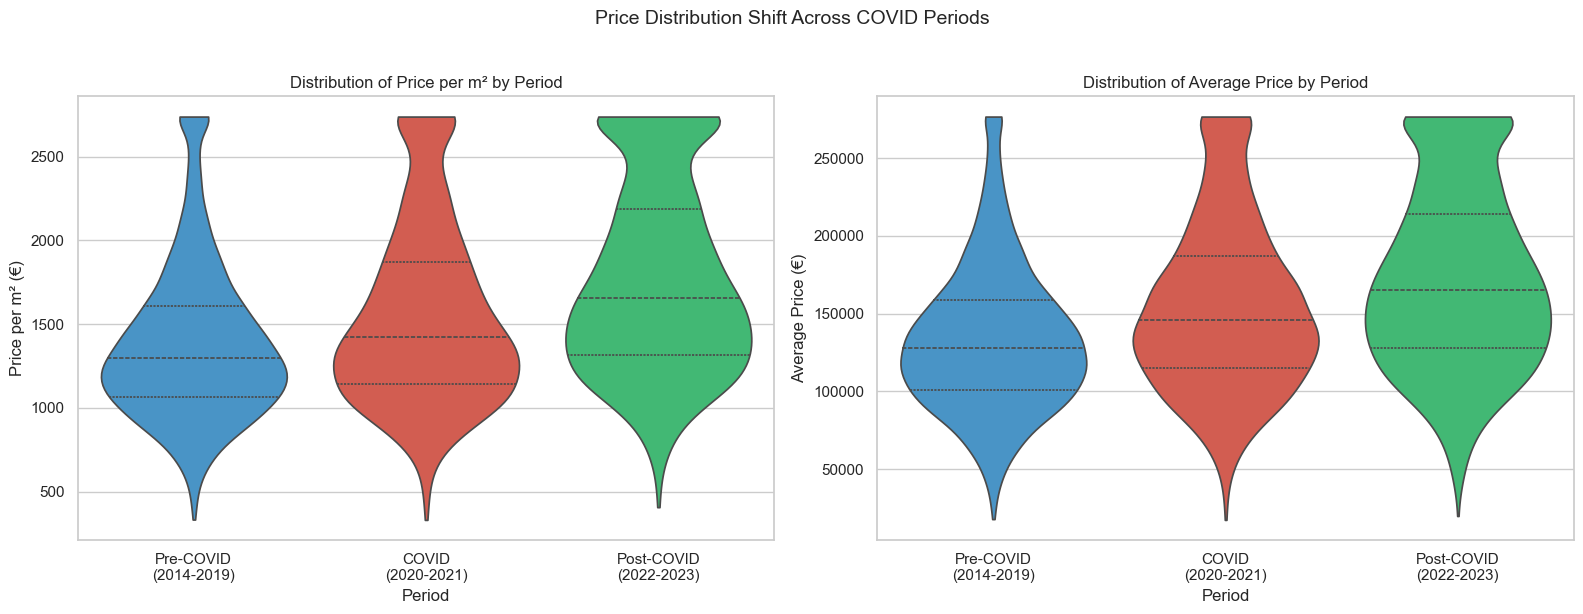

In [87]:
# Figure 11: Violin Plot — Price Distribution by Period

period_order = ['Pre-COVID\n(2014-2019)', 'COVID\n(2020-2021)', 'Post-COVID\n(2022-2023)']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Price per m²
sns.violinplot(
    data=data_region, x='Period', y='Prixm2Moyen',
    order=period_order,
    hue='Period',
    palette=['#3498db', '#e74c3c', '#2ecc71'],
    legend=False,
    inner='quartile',
    cut=0,
    ax=axes[0]
)
axes[0].set_xlabel('Period')
axes[0].set_ylabel('Price per m² (€)')
axes[0].set_title('Distribution of Price per m² by Period')

# Right: Average price
sns.violinplot(
    data=data_region, x='Period', y='PrixMoyen',
    order=period_order,
    hue='Period',
    palette=['#3498db', '#e74c3c', '#2ecc71'],
    legend=False,
    inner='quartile',
    cut=0,
    ax=axes[1]
)
axes[1].set_xlabel('Period')
axes[1].set_ylabel('Average Price (€)')
axes[1].set_title('Distribution of Average Price by Period')

plt.suptitle('Price Distribution Shift Across COVID Periods', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

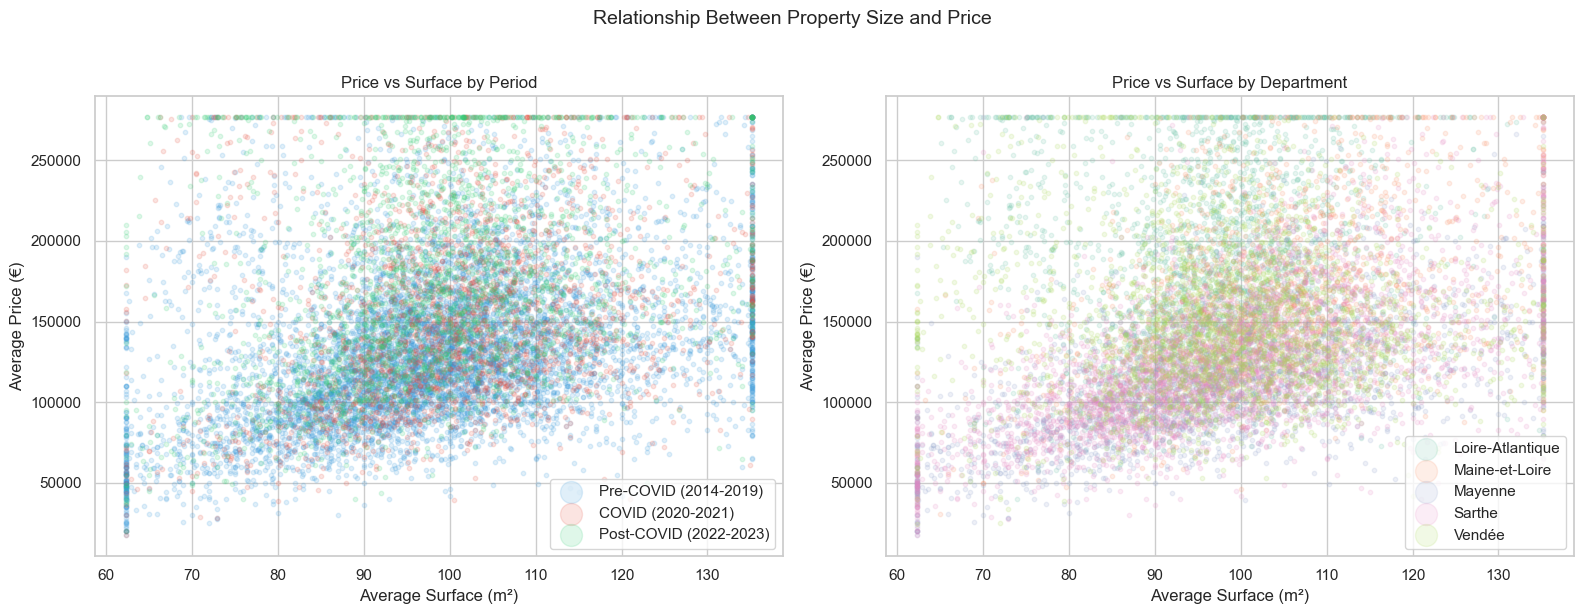

In [88]:
# Figure 12: Scatter Plot — Price vs Surface Area

period_order = ['Pre-COVID\n(2014-2019)', 'COVID\n(2020-2021)', 'Post-COVID\n(2022-2023)']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: colored by Period
scatter_colors = {
    'Pre-COVID\n(2014-2019)': '#3498db',
    'COVID\n(2020-2021)': '#e74c3c',
    'Post-COVID\n(2022-2023)': '#2ecc71'
}

for period in period_order:
    subset = data_region[data_region['Period'] == period]
    axes[0].scatter(
        subset['SurfaceMoy'], subset['PrixMoyen'],
        alpha=0.15, s=10, label=period.replace('\n', ' '),
        color=scatter_colors[period]
    )
axes[0].set_xlabel('Average Surface (m²)')
axes[0].set_ylabel('Average Price (€)')
axes[0].set_title('Price vs Surface by Period')
axes[0].legend(markerscale=5)

# Right panel: colored by Department
dept_palette = sns.color_palette('Set2', 5)
dept_names = sorted(data_region['Departement'].unique())
for i, dept in enumerate(dept_names):
    subset = data_region[data_region['Departement'] == dept]
    axes[1].scatter(
        subset['SurfaceMoy'], subset['PrixMoyen'],
        alpha=0.15, s=10, label=dept,
        color=dept_palette[i]
    )
axes[1].set_xlabel('Average Surface (m²)')
axes[1].set_ylabel('Average Price (€)')
axes[1].set_title('Price vs Surface by Department')
axes[1].legend(markerscale=5)

plt.suptitle('Relationship Between Property Size and Price', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()